<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 8, Time Series Fine-tuning**

Cuando el zero-shot no alcanza, hay tres caminos:

| Camino | Costo | Cuándo conviene |
|---|---|---|
| **RAG** | bajo, sin entrenar | series nuevas, patrones recurrentes, necesidad de explicar |
| **Fine-tuning** (este notebook) | medio, entrena una vez | la serie tiene una dinámica propia y estable, hay datos suficientes |
| **Entrenar desde cero** | alto | hay muchos datos y el dominio es muy particular |

---

# Fine-tuning


Importamos las librerias necesarias

In [ ]:
import time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Definimos el device, las semillas y el tamaño del plot

In [ ]:
torch.manual_seed(0); np.random.seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.figsize"] = (13, 4)
print("device:", DEV)

device: cuda


Cargamos el dataset

In [ ]:
URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
raw = pd.read_csv(URL, parse_dates=["date"]).rename(columns={"date": "timestamp"})
SERIES = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

Definimos parámetros

In [ ]:
L, H = 168, 24  # contexto de 1 semana, 24 horas de pronóstico
QUANTILES = [0.1, 0.5, 0.9]

In [ ]:
SERIE_OBJETIVO = "HUFL" # la serie que el modelo base nunca verá
SERIES_PRETRAIN = [s for s in SERIES if s != SERIE_OBJETIVO]

print("preentrenamiento:", SERIES_PRETRAIN)
print("objetivo (held-out):", SERIE_OBJETIVO)

preentrenamiento: ['HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
objetivo (held-out): HUFL


### Particiones temporales

* Definimos los cortes para todo el notebook.

* El gap de 24 horas entre bloques evita que una ventana de entrenamiento contenga horas que caen dentro de validación (las ventanas tienen largo L+H, así que se solapan si no se corta explícitamente).

In [ ]:
FIN_TRAIN = pd.Timestamp("2018-04-01")
FIN_VAL   = pd.Timestamp("2018-05-15")
# test va de FIN_VAL en adelante

In [ ]:
def ventanas(serie_valores, L=L, H=H, stride=1):
    """Convierte un vector en tensores (X, Y) de ventanas deslizantes."""
    X, Y = [], []
    for i in range(0, len(serie_valores) - L - H + 1, stride):
        X.append(serie_valores[i:i+L]); Y.append(serie_valores[i+L:i+L+H])
    return (torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(Y), dtype=torch.float32))

def bloque(serie, desde=None, hasta=None):
    s = raw[["timestamp", serie]].rename(columns={serie: "y"})
    if desde is not None: s = s[s.timestamp >= desde]
    if hasta is not None: s = s[s.timestamp < hasta]
    return s.y.to_numpy()

Datos de preentrenamiento: 6 series, solo el bloque de train

In [ ]:
Xp, Yp = [], []
for s in SERIES_PRETRAIN:
    x, y = ventanas(bloque(s, hasta=FIN_TRAIN), stride=2)
    Xp.append(x); Yp.append(y)
Xp, Yp = torch.cat(Xp), torch.cat(Yp)

Datos de la serie objetivo

In [ ]:
Xt, Yt = ventanas(bloque(SERIE_OBJETIVO, hasta=FIN_TRAIN), stride=1) # fine-tuning
Xv, Yv = ventanas(bloque(SERIE_OBJETIVO, FIN_TRAIN, FIN_VAL), stride=4) # validación
Xte, Yte = ventanas(bloque(SERIE_OBJETIVO, FIN_VAL), stride=4) # test

print(f"preentrenamiento : {len(Xp):,} ventanas (6 series)")
print(f"fine-tuning      : {len(Xt):,} ventanas ({SERIE_OBJETIVO})")
print(f"validación       : {len(Xv):,}   |   test: {len(Xte):,}")

preentrenamiento : 45,438 ventanas (6 series)
fine-tuning      : 15,145 ventanas (HUFL)
validación       : 217   |   test: 210


### El modelo: PatchTST-lite

Una versión mínima de la familia que vimos en la Clase 6:

1. **Instance norm** (tipo RevIN): cada ventana se normaliza con su propia media y desvío. Esto es lo que permite que un mismo modelo sirva a series de escalas distintas, es la clave del transfer.
2. **Patching**: la ventana de 168 horas se corta en 7 parches de 24, menos tokens, más contexto.
3. **Encoder Transformer** de 2 capas.
4. **Cabeza (head)** que produce H × 3 salidas: un valor por hora y por cuantil.

Entrenamos con **pinball loss** multi-cuantil (Clase 7): el modelo aprende la distribución, no solo la media.

* El backbone (patch embed + encoder) aprende la dinámica general de series de tiempo, la cabeza aprende cómo se traduce esa dinámica en esta serie. Por eso la primera estrategia de fine-tuning siempre es: congelar el backbone, reentrenar la cabeza (apuntando más hacia ser un Feature Extraction que un Fine-tuning).

In [ ]:
PATCH = 24
class PatchTSTLite(nn.Module):
    def __init__(self, L=L, H=H, patch=PATCH, d=64, heads=4, layers=2, nq=len(QUANTILES)):
        super().__init__()
        self.L, self.H, self.patch, self.nq = L, H, patch, nq
        self.n_patches = L // patch
        # Backbone: lo que se transfiere entre series
        self.embed = nn.Linear(patch, d)
        self.pos   = nn.Parameter(torch.randn(1, self.n_patches, d) * .02)
        enc = nn.TransformerEncoderLayer(d, heads, d*4, dropout=.1,
                                         batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, layers)
        # Cabeza: lo específico de la serie
        self.head = nn.Linear(self.n_patches * d, H * nq)

    def forward(self, x): # x: (B, L) valores crudos
        mu = x.mean(1, keepdim=True)
        sd = x.std(1, keepdim=True) + 1e-5
        z = (x - mu) / sd  # instance norm, habilita el transfer
        z = z.view(-1, self.n_patches, self.patch)
        z = self.encoder(self.embed(z) + self.pos).flatten(1)
        out = self.head(z).view(-1, self.H, self.nq)
        return out * sd.unsqueeze(-1) + mu.unsqueeze(-1) # desnormalización

def pinball_loss(pred, y, quantiles=QUANTILES):
    """pred: (B,H,Q) | y: (B,H),  pérdida promedio sobre horizontes y cuantiles"""
    y = y.unsqueeze(-1)
    q = torch.tensor(quantiles, device=pred.device).view(1, 1, -1)
    d = y - pred
    return torch.maximum(q * d, (q - 1) * d).mean()

In [ ]:
m = PatchTSTLite()
print(f"parámetros totales: {sum(p.numel() for p in m.parameters()):,}")
print(f"Backbone: {sum(p.numel() for n,p in m.named_parameters() if not n.startswith('head')):,}")
print(f"Cabeza (head): {sum(p.numel() for n,p in m.named_parameters() if n.startswith('head')):,}")

parámetros totales: 134,344
Backbone: 102,016
Cabeza (head): 32,328


/tmp/ipykernel_5284/3609925915.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, layers)


### El loop de entrenamiento

Esta función sirve para el preentrenamiento y para todas las variantes de fine-tuning. Incluye early stopping sobre la validación temporal y devuelve el mejor estado, no el último.

In [ ]:
def entrenar(modelo, X, Y, Xval, Yval, epochs=12, lr=1e-3, bs=128,
             params=None, paciencia=3, log=True):
    modelo = modelo.to(DEV)
    params = params if params is not None else modelo.parameters()
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    ds = torch.utils.data.TensorDataset(X, Y)
    dl = torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=True)
    Xval, Yval = Xval.to(DEV), Yval.to(DEV)

    mejor, mejor_estado, sin_mejora, hist = np.inf, None, 0, []
    for ep in range(epochs):
        modelo.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEV), yb.to(DEV)
            opt.zero_grad()
            loss = pinball_loss(modelo(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            opt.step()

        modelo.eval()
        with torch.no_grad():
            vl = pinball_loss(modelo(Xval), Yval).item()
        hist.append(vl)
        if vl < mejor - 1e-4:
            mejor, mejor_estado, sin_mejora = vl, copy.deepcopy(modelo.state_dict()), 0
        else:
            sin_mejora += 1
        if log:
            print(f"  época {ep+1:2d} | val pinball {vl:.4f}" + ("  *" if sin_mejora == 0 else ""))
        if sin_mejora >= paciencia:
            if log: print("  early stopping")
            break

    modelo.load_state_dict(mejor_estado)
    return modelo, hist

In [ ]:
@torch.no_grad()
def evaluar(modelo, X, Y):
    modelo.eval()
    p = modelo(X.to(DEV)).cpu().numpy()          # (B,H,Q)
    y = Y.numpy()
    q50 = p[:, :, QUANTILES.index(0.5)]
    mae = np.abs(y - q50).mean()
    pl = np.mean([np.maximum(q*(y-p[:,:,i]), (q-1)*(y-p[:,:,i])).mean()
                  for i, q in enumerate(QUANTILES)])
    cob = np.mean((y >= p[:, :, 0]) & (y <= p[:, :, -1]))
    return {"MAE": mae, "Pinball": pl, "Cobertura80": cob}

### Preentrenamiento del modelo base

El modelo base ve 6 series y nunca la serie objetivo. Este es nuestro "foundation model casero": sabe de series de tiempo en general, no de esta serie en particular.

In [ ]:
t0 = time.time()

# validamos el preentrenamiento con una serie de pretrain, no con la objetivo
Xp_val, Yp_val = ventanas(bloque("OT", FIN_TRAIN, FIN_VAL), stride=4)

base, hist_base = entrenar(PatchTSTLite(), Xp, Yp, Xp_val, Yp_val, epochs=10, lr=1e-3)
print(f"\nPreentrenamiento listo en {time.time()-t0:.0f}s")

ESTADO_BASE = copy.deepcopy(base.state_dict())     # el "checkpoint" congelado

/tmp/ipykernel_5284/3609925915.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, layers)


  época  1 | val pinball 0.4227  *
  época  2 | val pinball 0.4275
  época  3 | val pinball 0.4205  *
  época  4 | val pinball 0.4210
  época  5 | val pinball 0.4177  *
  época  6 | val pinball 0.4090  *
  época  7 | val pinball 0.4167
  época  8 | val pinball 0.4108
  época  9 | val pinball 0.4076  *
  época 10 | val pinball 0.4095

Preentrenamiento listo en 40s


### Las cinco estrategias

Ahora comparamos, **todas evaluadas sobre el mismo test**:

| # | Estrategia | Qué hace |
|---|---|---|
| 0 | **Naive estacional** | el piso obligatorio: repetir la semana anterior |
| 1 | **Zero-shot** | el modelo base, sin tocar. Nunca vio la serie objetivo |
| 2 | **Fine-tune de la cabeza** | backbone congelado, solo se reentrena `head` |
| 3 | **Fine-tune completo** | todo el modelo, con LR **10× más bajo** |
| 4 | **Desde cero** | mismo modelo, entrenado solo con la serie objetivo |


In [ ]:
resultados, curvas = {}, {}

Naive Estacional

In [ ]:
naive_pred = Xte[:, -168:][:, :H].numpy()
resultados["0. Naive estacional"] = {
    "MAE": np.abs(Yte.numpy() - naive_pred).mean(), "Pinball": np.nan, "Cobertura80": np.nan}

Zero-shot

In [ ]:
zs = PatchTSTLite().to(DEV); zs.load_state_dict(ESTADO_BASE)
resultados["1. Zero-shot (base)"] = evaluar(zs, Xte, Yte)

/tmp/ipykernel_5284/3609925915.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, layers)


Fine-tune solo la cabeza, backbone congelado

In [ ]:
m2 = PatchTSTLite().to(DEV); m2.load_state_dict(ESTADO_BASE)

for n, p in m2.named_parameters():
    p.requires_grad = n.startswith("head")  # el congelamiento

entrenables = [p for p in m2.parameters() if p.requires_grad]
m2, curvas["2. Head-only"] = entrenar(m2, Xt, Yt, Xv, Yv, epochs=12, lr=1e-3, params=entrenables)
resultados["2. Fine-tune cabeza"] = evaluar(m2, Xte, Yte)

/tmp/ipykernel_5284/3609925915.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, layers)


  época  1 | val pinball 0.9605  *
  época  2 | val pinball 0.9573  *
  época  3 | val pinball 0.9573
  época  4 | val pinball 0.9566  *
  época  5 | val pinball 0.9540  *
  época  6 | val pinball 0.9541
  época  7 | val pinball 0.9619
  época  8 | val pinball 0.9594
  early stopping


Fine-tune completo con LR bajo

In [ ]:
m3 = PatchTSTLite().to(DEV); m3.load_state_dict(ESTADO_BASE)
m3, curvas["3. Full fine-tune"] = entrenar(m3, Xt, Yt, Xv, Yv, epochs=12, lr=1e-4)
resultados["3. Fine-tune completo"] = evaluar(m3, Xte, Yte)

/tmp/ipykernel_5284/3609925915.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, layers)


  época  1 | val pinball 0.9501  *
  época  2 | val pinball 0.9456  *
  época  3 | val pinball 0.9421  *
  época  4 | val pinball 0.9406  *
  época  5 | val pinball 0.9363  *
  época  6 | val pinball 0.9379
  época  7 | val pinball 0.9363
  época  8 | val pinball 0.9355  *
  época  9 | val pinball 0.9345  *
  época 10 | val pinball 0.9324  *
  época 11 | val pinball 0.9321  *
  época 12 | val pinball 0.9357


Entrenar desde cero (sin pre-entrenamiento)

In [ ]:
m4, curvas["4. Desde cero"] = entrenar(PatchTSTLite(), Xt, Yt, Xv, Yv, epochs=12, lr=1e-3)
resultados["4. Desde cero"] = evaluar(m4, Xte, Yte)

/tmp/ipykernel_5284/3609925915.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, layers)


  época  1 | val pinball 1.0417  *
  época  2 | val pinball 1.0142  *
  época  3 | val pinball 1.0082  *
  época  4 | val pinball 0.9876  *
  época  5 | val pinball 0.9735  *
  época  6 | val pinball 0.9723  *
  época  7 | val pinball 0.9806
  época  8 | val pinball 0.9658  *
  época  9 | val pinball 0.9750
  época 10 | val pinball 0.9565  *
  época 11 | val pinball 0.9599
  época 12 | val pinball 0.9624


In [ ]:
tabla = pd.DataFrame(resultados).T
tabla["Skill vs naive"] = 1 - tabla.MAE / tabla.loc["0. Naive estacional", "MAE"]
print(tabla.round(3).to_string())

                         MAE  Pinball  Cobertura80  Skill vs naive
0. Naive estacional    4.198      NaN          NaN           0.000
1. Zero-shot (base)    2.938    0.945        0.759           0.300
2. Fine-tune cabeza    2.873    0.900        0.784           0.316
3. Fine-tune completo  2.831    0.889        0.769           0.326
4. Desde cero          2.872    0.911        0.770           0.316


Grafica comparativa de MAE y Curvas de Fine-tuning

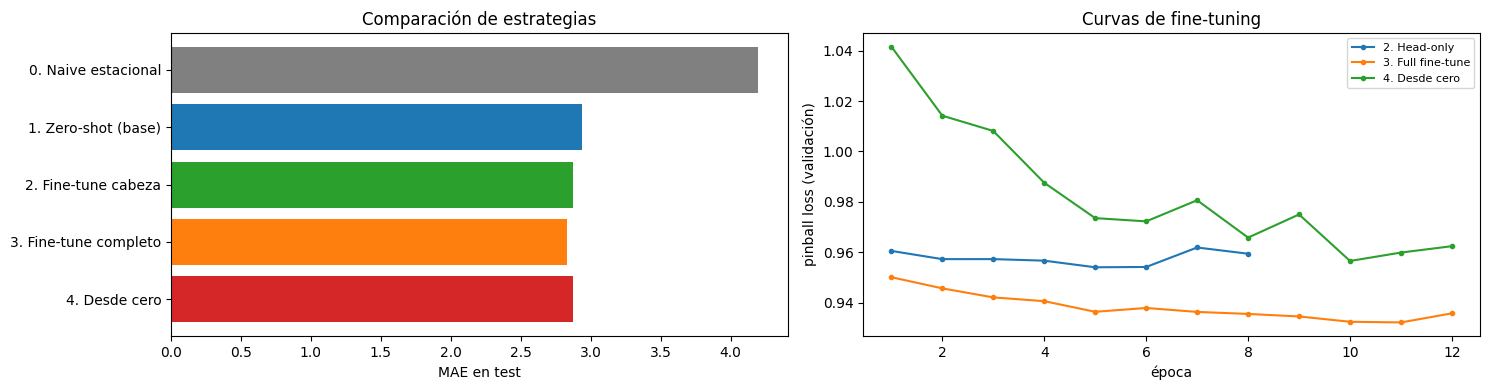

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

col = ["gray", "tab:blue", "tab:green", "tab:orange", "tab:red"]
ax[0].barh(tabla.index, tabla.MAE, color=col[:len(tabla)])
ax[0].set_xlabel("MAE en test")
ax[0].set_title("Comparación de estrategias")
ax[0].invert_yaxis()

for k, h in curvas.items():
    ax[1].plot(range(1, len(h)+1), h, marker="o", ms=3, label=k)
ax[1].set_xlabel("época"); ax[1].set_ylabel("pinball loss (validación)")
ax[1].set_title("Curvas de fine-tuning"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Olvido catastrófico

El costo oculto del fine-tuning: al especializar el modelo en una serie, empeora en las demás.

Esto importa en producción: si tenés **un modelo global sirviendo 5.000 series** y lo fine-tuneamos
para la serie estrella, podemos estar degradando silenciosamente las otras 4.999.

In [ ]:
X_otras, Y_otras = [], []
for s in SERIES_PRETRAIN:
    x, y = ventanas(bloque(s, FIN_VAL), stride=8)
    X_otras.append(x); Y_otras.append(y)
X_otras, Y_otras = torch.cat(X_otras), torch.cat(Y_otras)

olvido = pd.DataFrame({
    "en la serie objetivo": [evaluar(zs, Xte, Yte)["MAE"],
                             evaluar(m2, Xte, Yte)["MAE"],
                             evaluar(m3, Xte, Yte)["MAE"]],
    "en las otras 6 series": [evaluar(zs, X_otras, Y_otras)["MAE"],
                              evaluar(m2, X_otras, Y_otras)["MAE"],
                              evaluar(m3, X_otras, Y_otras)["MAE"]],
}, index=["Base (zero-shot)", "Fine-tune cabeza", "Fine-tune completo"])

olvido["Δ objetivo"] = olvido["en la serie objetivo"] - olvido.loc["Base (zero-shot)", "en la serie objetivo"]
olvido["Δ otras"]    = olvido["en las otras 6 series"] - olvido.loc["Base (zero-shot)", "en las otras 6 series"]
print(olvido.round(3).to_string())

                    en la serie objetivo  en las otras 6 series  Δ objetivo  Δ otras
Base (zero-shot)                   2.938                  0.989       0.000    0.000
Fine-tune cabeza                   2.873                  0.971      -0.066   -0.018
Fine-tune completo                 2.831                  0.976      -0.107   -0.013


* Δ negativo = mejora, Δ positivo = degradación")
* Si 'Δ otras' es positivo, el fine-tuning se pagó con el resto del portafolio.

**Mitigaciones habituales del olvido catastrófico:**

- Fine-tunear **solo la cabeza** (o adaptadores / LoRA) en lugar del modelo completo.
- Mezclar en el fine-tuning un porcentaje de datos de las otras series (replay).
- Mantener un modelo por segmento en lugar de uno solo (con el costo operativo que eso implica).
- Y sobre todo: medir siempre en el portafolio completo, no solo en la serie que motivó el fine-tuning.